In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.insert(0, project_root)

1. Define potentials
2. Define masses
3. Define 

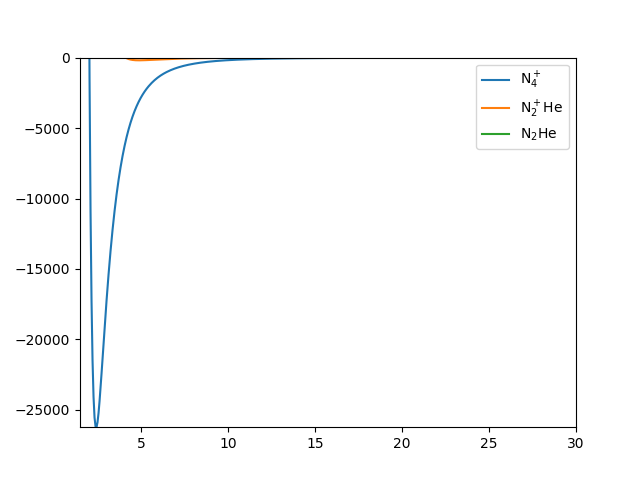

In [2]:
# Define potentials 
from tbr.potentials import LJ, dLJ
from tbr.constants import ANG2BOH, K2HAR

# N4p_de = 52.2 kcal/mol
N4p_de = 0.083186 # (Eh)
N4p_re = 1.382*ANG2BOH # (A -> a0)
N2_alpha = 1.710 # A^3
N4p_c4 = N2_alpha*(ANG2BOH**3)/2 # C4 = alpha/2
N4p_c8 = N4p_c4**2/(4*N4p_de)

# J. Chem. Phys., Vol. 95, No.8, 15 October 1991
# doi: 10.1063/1.461604
# ESMSV potential
N2He_de =  2.15*0.0000367493 # (meV -> Eh)
N2He_re = 3.66*ANG2BOH # (A -> a0)

N2He_c6 = 6093*(3.67493e-5)*ANG2BOH**6 # (meV A^6 -> Eh*a0^6)
N2He_c12 =  N2He_c6**2/(4*N2He_de)

N2pHe_de = 133.12*0.0000046 # cm^-1 -> Eh
N2pHe_re = 6.199
He_alpha = 0.208 # A^3
N2pHe_c4 = He_alpha*ANG2BOH**3/2 
N2pHe_c8 = N2pHe_c4**2/(4*N2pHe_de)

N4_de = 173.9 # kcal/mol
N4_re = 1.386*ANG2BOH # (A)
N4_c6 = 1
N4_c12 = 1

v_N4p = LJ(n=4, m=8, cn = N4p_c4, cm = N4p_c8)
dv_N4p = dLJ(n=4, m=8, cn = N4p_c4, cm = N4p_c8)

v_N2He = LJ(n=6, m=12, cn = N2He_c6, cm = N2He_c12)
dv_N2He = dLJ(n=6, m=12, cn = N2He_c6, cm = N2He_c12)

v_N2pHe = LJ(n=4, m=8, cn = N2pHe_c4, cm = N2pHe_c8)
dv_N2pHe = dLJ(n=4, m=8, cn = N2pHe_c4, cm = N2pHe_c8)

# N2 + N2p + He
v_funcs = (v_N4p, v_N2pHe, v_N2He)
dv_funcs = (dv_N4p, dv_N2pHe, dv_N2He)

# Plot potentials
x = np.linspace(1.3, 30, 500)
plt.figure()
plt.plot(x, v_N4p(x)/K2HAR, label = f'N$_4^+$')
plt.plot(x, v_N2pHe(x)/K2HAR, label = f'N$_2^+$He')
plt.plot(x, v_N2He(x)/K2HAR, label = f'N$_2$He')
plt.xlim(1.5, 30)
plt.ylim(min(v_N4p(x))/K2HAR, 1e-2) # N4+
# plt.ylim(min(v_N2pHe(x))/K2HAR, 1e-2) # N2+He
# plt.ylim(min(v_N2He(x))/K2HAR, 1e-2) # N2He
plt.legend()
plt.show()

In [3]:
# Trajectory parameters
masses = (2*14.007, 2*14.007, 4.0026) # N2, N2+, He
m1, m2, m3 = masses
E0 = 1000 # Kelvin
R0 = 1000.0
dR0 = 0.1*R0
b0 = 0

In [4]:
# Simulate one trajectory
from tbr.simulator import run_trajectory_worker
import time

seed = int(np.random.random()*8923)
print(f'Running trajectory with seed {seed}...')
t_stop, r_stop, r_tol, a_tol = 3, 3, 1e-08, 1e-10 # (1e-11, 1e-13)
task_data = m1, m2, m3, E0, b0, R0, dR0, v_funcs, dv_funcs, t_stop, r_stop, r_tol, a_tol, seed
t0 = time.time()
solution = run_trajectory_worker(task_data=task_data)
tf = time.time()
print(f'Trajectory run in {tf-t0} s')

Running trajectory with seed 8345...
Energy drift 1.874840850710907e-09 Hartree
Trajectory run in 9.343432188034058 s


[0 0 0 1 0]
[[ 9.26728370e+02  9.26728284e+02  9.26727428e+02 ...  6.75960163e+02
   9.50889757e+02  1.33681287e+03]
 [-3.26381498e+02 -3.26381468e+02 -3.26381166e+02 ... -2.38064246e+02
  -3.34890819e+02 -4.70807846e+02]
 [ 2.66643672e+02  2.66643647e+02  2.66643401e+02 ...  1.94480743e+02
   2.73580824e+02  3.84614885e+02]
 [-0.00000000e+00  2.12964443e-19  2.57687429e-17 ...  1.54551126e-03
   1.97960441e-03  2.58906287e-03]
 [ 0.00000000e+00 -7.50032653e-20 -9.07541107e-18 ... -5.44308661e-04
  -6.97190539e-04 -9.11833764e-04]
 [ 2.59726645e+02  2.59726598e+02  2.59726134e+02 ... -6.04517968e+02
  -7.53717453e+02 -9.63151181e+02]]


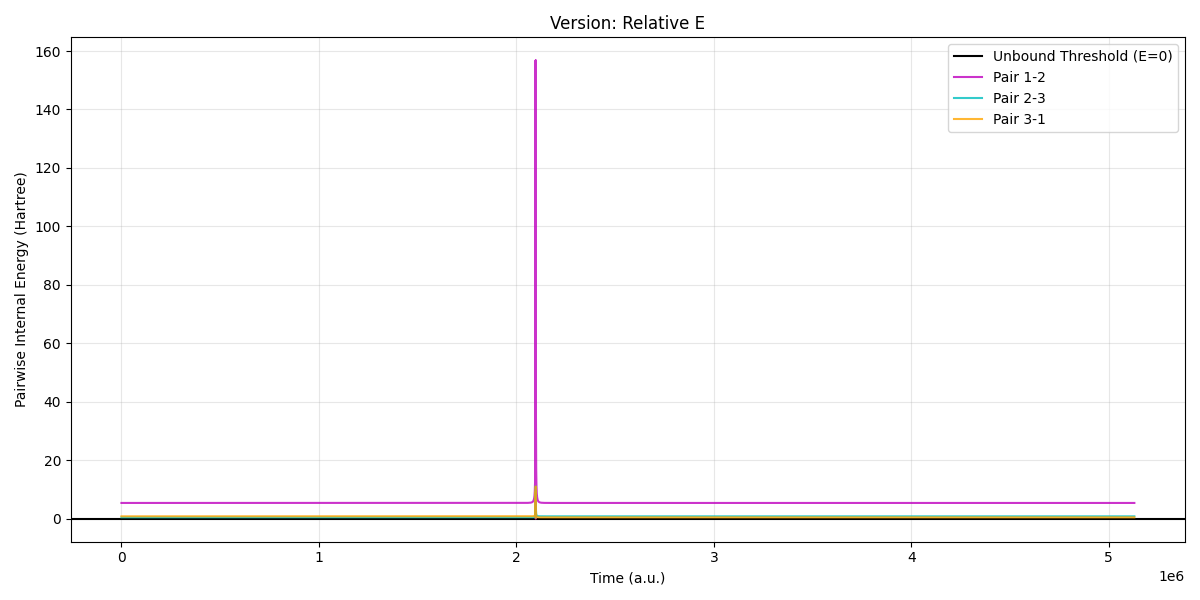

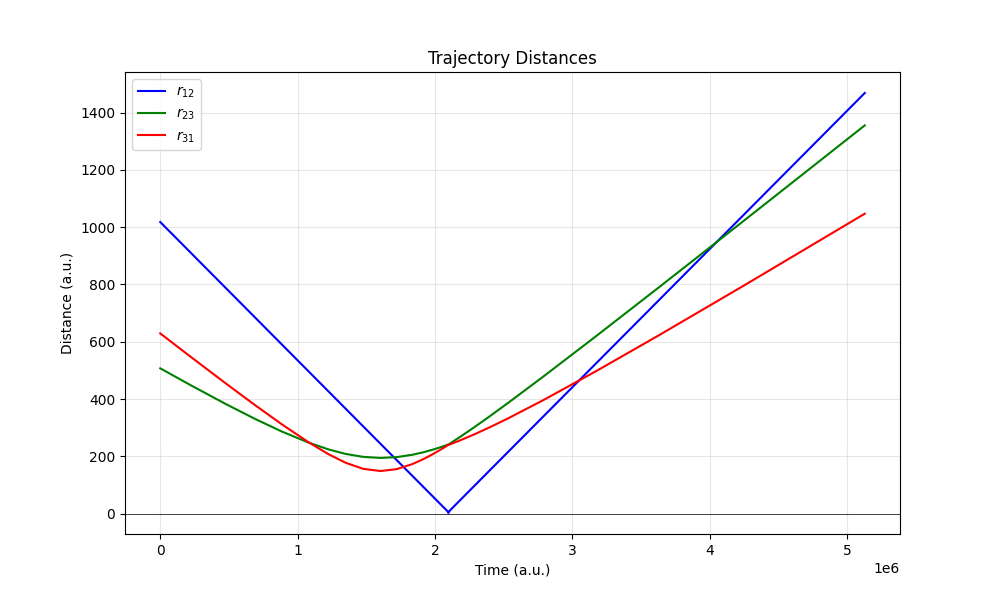

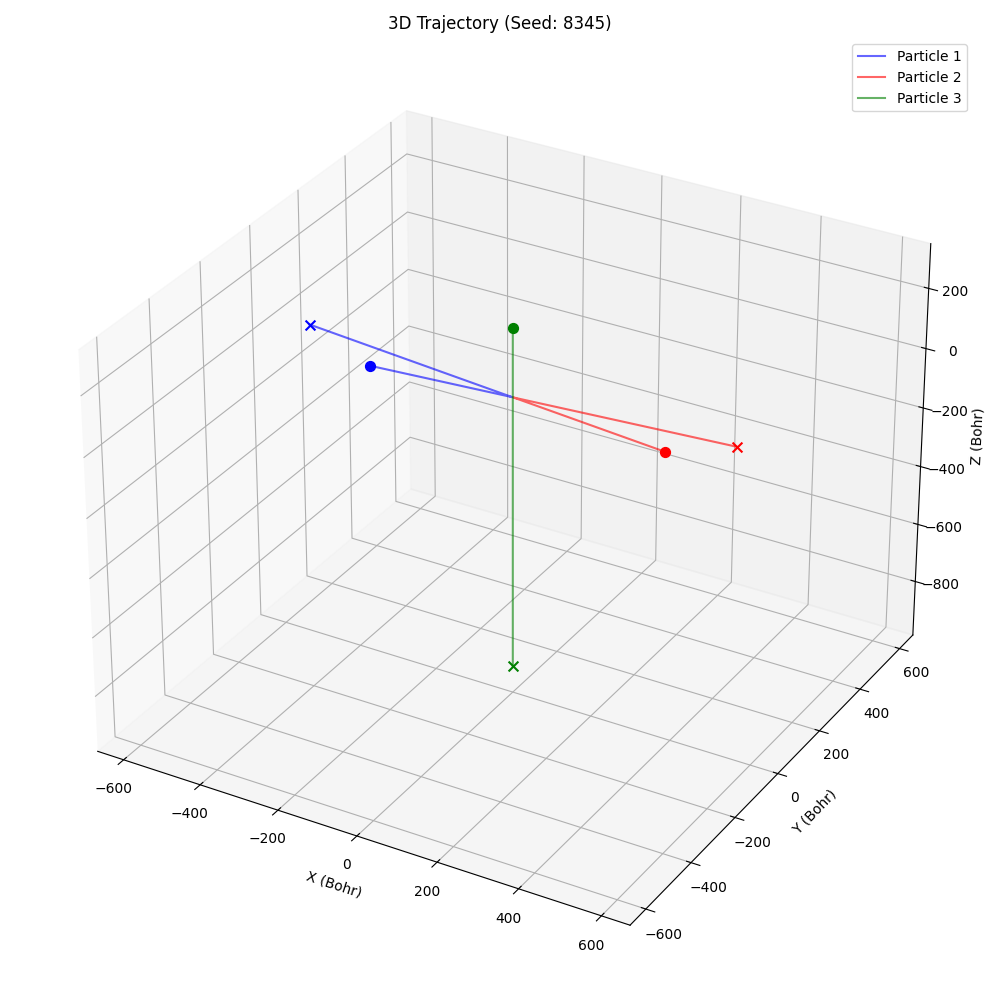

In [5]:
from tbr.simulator import get_distances_from_solution
from tbr.plotters import plot_distances, plot_3d_motion, plot_relative_e

# Observables
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T

print(n_res)
print(rho_vec)
plot_distances(data_block, seed, E0, b0)
# plot_2d_motion(data_block, seed)
plot_3d_motion(data_block, m1, m2, m3, seed)
plot_relative_e(solution, masses, v_funcs)
# plot_energy_trace(solution, masses, v_funcs)
# animate_3d_forces(solution, masses, dv_funcs, scale = 0,
#                   filename='trajectory_forces7.gif', duration_seconds=10,
#                   azim=0,elev=30)
plt.show()

Running trajectory with seed 26341...
Energy drift 1.849884573431812e-09 Hartree
Trajectory run in 0.2519199848175049 s
Running trajectory with seed 24897...
Energy drift 1.967657993842426e-09 Hartree
Trajectory run in 0.30372190475463867 s
Running trajectory with seed 31801...
Energy drift 1.9232990991382808e-09 Hartree
Trajectory run in 0.22500324249267578 s
Running trajectory with seed 26525...
Energy drift 1.8138100876395787e-09 Hartree
Trajectory run in 0.1752147674560547 s
Running trajectory with seed 26511...
Energy drift 2.1139271729028915e-09 Hartree
Trajectory run in 0.16354036331176758 s
Running trajectory with seed 31380...
Energy drift 1.9369268691661785e-09 Hartree
Trajectory run in 0.1730358600616455 s
Running trajectory with seed 27276...
Energy drift 1.929663584574349e-09 Hartree
Trajectory run in 0.2293407917022705 s
Running trajectory with seed 29280...
Energy drift 1.869743466553341e-09 Hartree
Trajectory run in 0.2530961036682129 s
Running trajectory with seed 2613

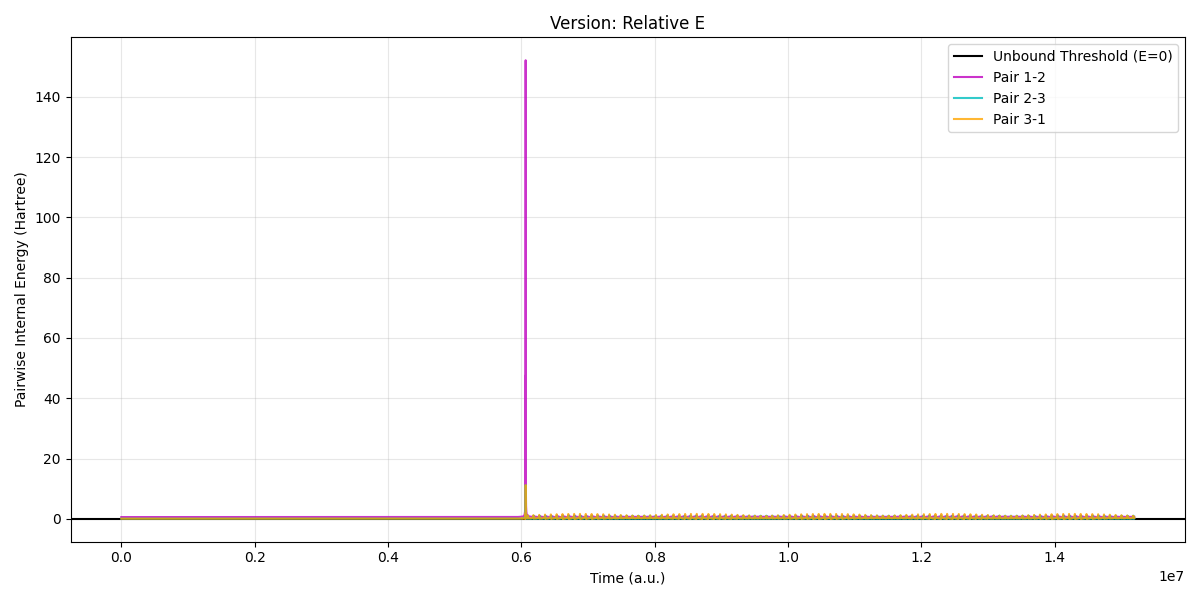

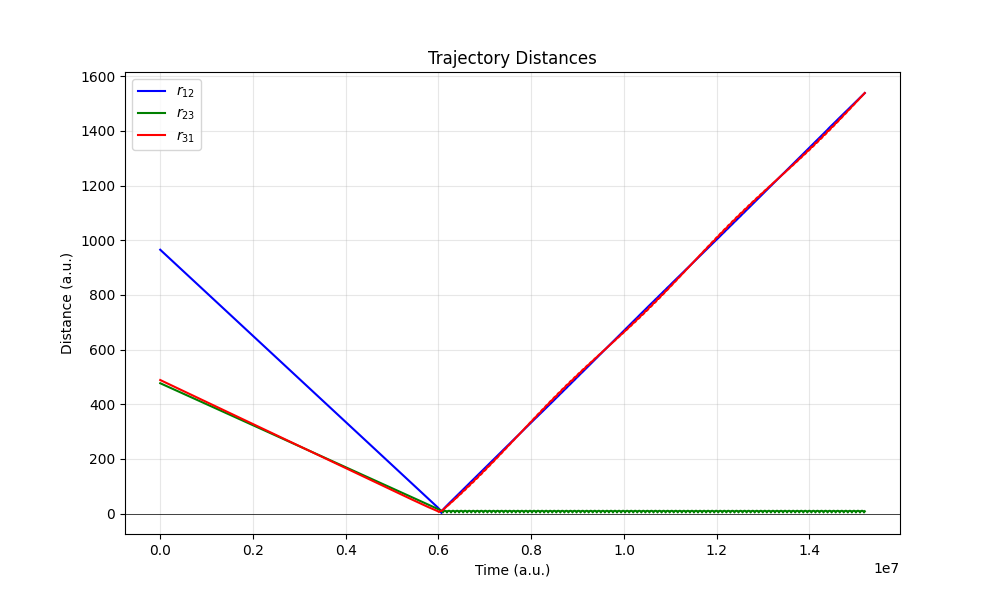

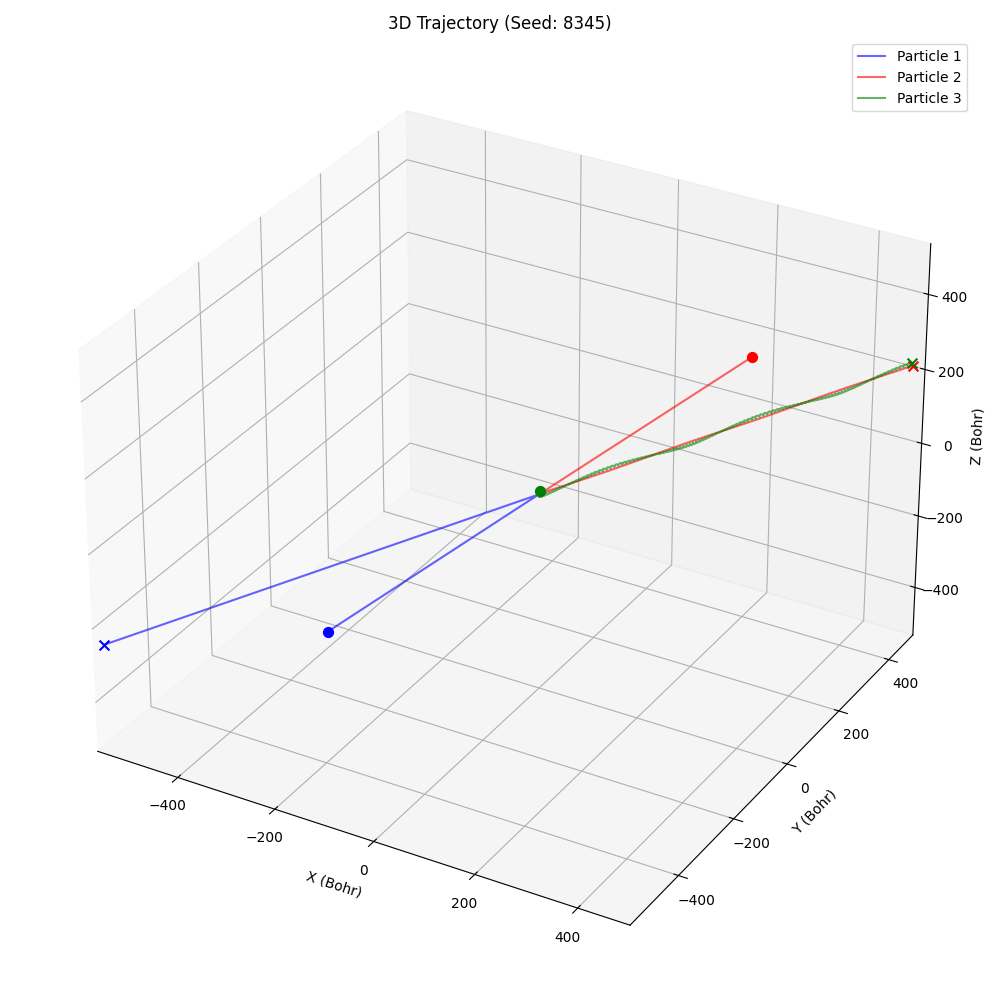

In [6]:
# Simulate until a reaction is found. 
masses = (2*14.007, 2*14.007, 4.0026) # N2, N2+, He
m1, m2, m3 = masses
E0 = 100 # Kelvin
R0 = 1000.0
dR0 = 0.1*R0
b0 = 0

t_stop, r_stop, r_tol, a_tol = 3, 3, 1e-08, 1e-10 # (1e-11, 1e-13)
task_data = m1, m2, m3, E0, b0, R0, dR0, v_funcs, dv_funcs, t_stop, r_stop, r_tol, a_tol, seed
def run_t():
    seed = int(np.random.random()*8923) + 23013
    print(f'Running trajectory with seed {seed}...')
    t_stop, r_stop, r_tol, a_tol = 3, 3, 1e-08, 1e-10 # (1e-11, 1e-13)
    task_data = m1, m2, m3, E0, b0, R0, dR0, v_funcs, dv_funcs, t_stop, r_stop, r_tol, a_tol, seed
    t0 = time.time()
    solution = run_trajectory_worker(task_data=task_data)
    tf = time.time()
    print(f'Trajectory run in {tf-t0} s')
    
    return solution

solution = run_t()
n_res = solution['n_res']
times = solution['times']
rho_vec = solution['positions_rho']
p_vec = solution['momenta_p']

while (n_res[3] == 1): # search for non-dissociative trajectories 
    solution = run_t()
    n_res = solution['n_res']
    times = solution['times']
    rho_vec = solution['positions_rho']
    p_vec = solution['momenta_p']

r12, r23, r31 = get_distances_from_solution(
            np.vstack([rho_vec, p_vec]), m1, m2
        )

data_block = np.vstack([
            solution['times'], 
            r12, r23, r31,
            solution['positions_rho'], 
            solution['momenta_p']
        ]).T
print(n_res)
plot_distances(data_block, seed, E0, b0)
# plot_2d_motion(data_block, seed)
plot_3d_motion(data_block, m1, m2, m3, seed)
plot_relative_e(solution, masses, v_funcs)
# plot_energy_trace(solution, masses, v_funcs)
# animate_3d_forces(solution, masses, dv_funcs, scale = 0,
#                   filename='trajectory_forces7.gif', duration_seconds=10,
#                   azim=0,elev=30)
plt.show()

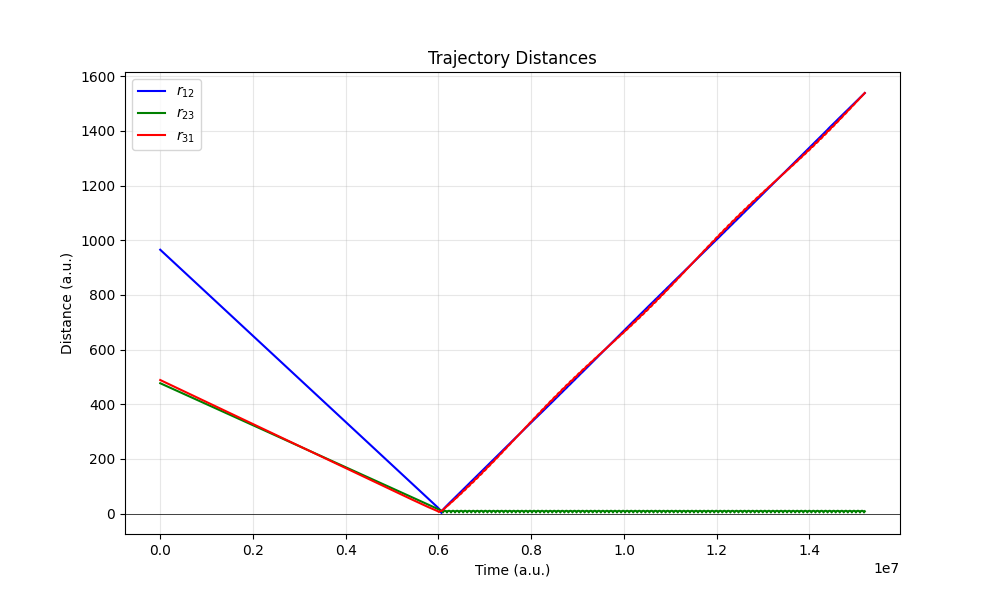

In [12]:
plot_distances(data_block, seed, E0, b0)
# plot_3d_motion(data_block, m1, m2, m3, seed)
plt.savefig('n4_2d.png', dpi=300)

In [7]:
# Impact parameter scan
from tbr.simulator import run_b_scan

b_values = np.linspace(0, 20, 3)
try:
    run_b_scan(
        b_range=b_values, num_traj_per_b=30,
        masses=masses, E0=E0, R0=R0, v_funcs=v_funcs,
        dv_funcs=dv_funcs,
        summary_file='N4_sample.csv',
        save_detailed=True 
    )
except RuntimeError as e:
    print(f'Multiprocessing error: {e}')

Starting Scan over b0: [ 0. 10. 20.]
Summary will be saved to: N4_sample.csv

--- Running batch for b0 = 0.00 ---
  Finished b0=0.00. Runtime: 43.83s. Rej: 0
  Stats: n12=0, n23=0, n31=0, nd=30, nc=0

--- Running batch for b0 = 10.00 ---
  Finished b0=10.00. Runtime: 36.93s. Rej: 0
  Stats: n12=0, n23=0, n31=0, nd=30, nc=0

--- Running batch for b0 = 20.00 ---
  Finished b0=20.00. Runtime: 48.39s. Rej: 0
  Stats: n12=0, n23=0, n31=0, nd=30, nc=0


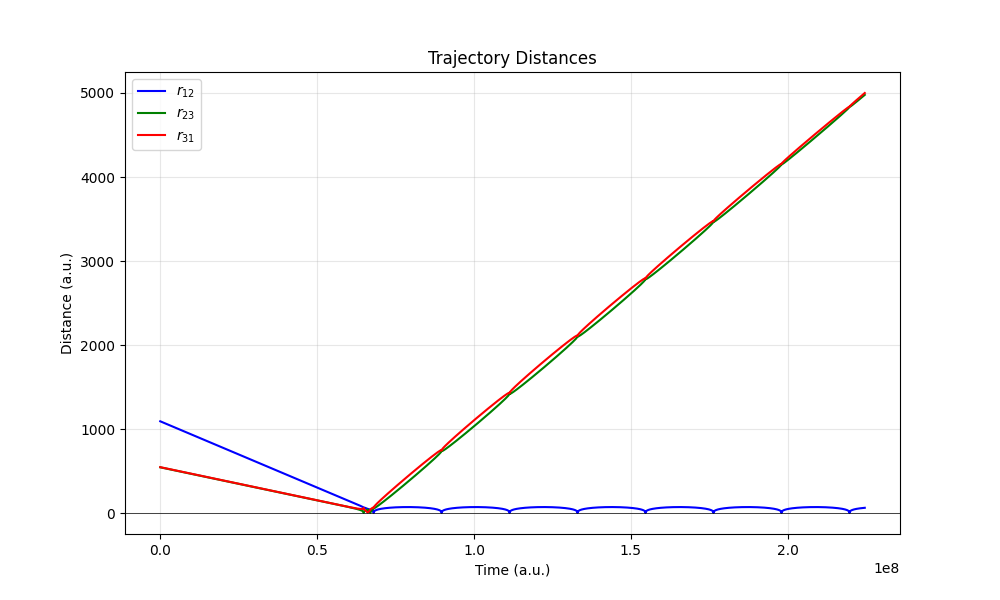

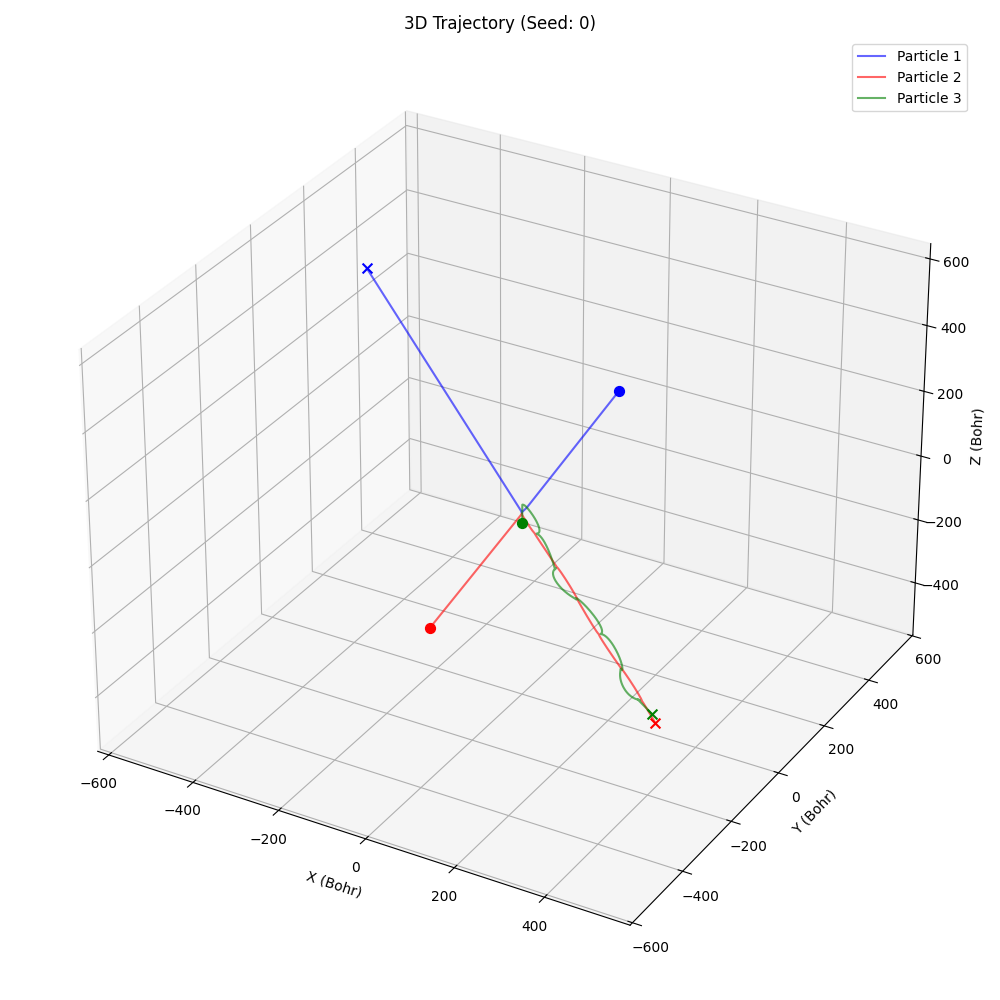

In [9]:
# The save_detailed=True saves each trajectory as a numpy file. We can plot any of the trajectories:
# The columns are:
# time (a.u.), r12, r23, r31, rho (6D), P (6D) 
reactive = np.load('results/traj_E1.00e+00_b0.00_seed35282550.npy')
tx = reactive[:,0]
r12 = reactive[:,1]
r23 = reactive[:,2]
r31 = reactive[:,3]
rho_vec = reactive[:, 4:10]
p_vec = reactive[:, 10:]
plot_distances(reactive, 0, 0, 0)
plot_3d_motion(data_block, m1, m2, m3, 0)


In [10]:
import pandas as pd
# from pathlib import Path

# base_dir = Path('n4')

# Cluster results
data = pd.read_csv('results/n4_short.txt')

In [11]:
def find_bmax(opac, b_values, window_size=3, frac=0):
    '''
    Function to find bmax.
    P(bmax) = max(opac)*F
    where F is a fraction of the maximum value set by the user. 
    We find the best agreement with the data comes from frac=10_successful_trajectories(b=bmax)/total_#_trajectories(b=0)
    '''
    opac = np.array(opac)
    b_values = np.array(b_values)

    if len(opac) == 0:
        return 0.0

    ref_val = np.max(opac) if len(opac) > 0 else 1.0
    cutoff = ref_val*frac

    if len(opac) < window_size:
        return b_values[-1] # Data too short, return max b

    windows = np.lib.stride_tricks.sliding_window_view(opac, window_size)

    if frac > 0:
        mask = np.all(windows < cutoff, axis=1)
    else:
        mask = np.all(windows == 0, axis=1)

    indices = np.where(mask)[0]

    if indices.size > 0:
        first_index = indices[0]
        bmax = b_values[first_index]
        return bmax
    else:
        # Integrate everything
        return b_values[-1]
    
def opacity(input, output_csv=None):
    if isinstance(input, pd.DataFrame):
        df = input
    else:
        df = pd.read_csv(input)

    grouped = df.groupby(['e','b']).agg({
        'n12': 'sum',
        'n23': 'sum',
        'n31': 'sum',
        'nd': 'sum',
        'nc': 'sum'
    }).reset_index()

    grouped['nT'] = grouped['n12'] + grouped['n23'] + grouped['n31'] + grouped['nd']
    grouped['n_AB'] = grouped['n23'] + grouped['n31']
    grouped['n_BB'] = grouped['n12'] 

    nT = grouped['nT'].replace(0, np.nan)

    grouped['p_AB'] = grouped['n_AB'] / nT
    grouped['p_AB_err'] = (np.sqrt(grouped['n_AB'])/nT)*np.sqrt((nT-grouped['n_AB'])/nT)

    grouped['p_BB'] = grouped['n_BB'] / nT
    grouped['p_BB_err'] = (np.sqrt(grouped['n_BB'])/nT)*np.sqrt((nT-grouped['n_BB'])/nT)

    df_results = grouped.fillna(0)

    if output_csv:
        df_results.to_csv(output_csv, index=False)
        print(f'Results saved to {output_csv}')
    
    return df_results

def opac_bmax(input_data, tolerance_numerator=2, window_size=3):

    if isinstance(input_data, pd.DataFrame):
        df = input_data.copy()
    else:
        df = opacity(input_data)

    # Find bmax for each 'e' group
    def get_group_bmax(group):
        group = group.sort_values('b')
        b = group['b'].values

        count_cols = ['n12','n23','n31','nd','nc']

        if all(col in group.columns for col in count_cols):
            first_row = group.iloc[0]
            N = int(sum(first_row[col] for col in count_cols))
        else:
            print(f"Warning: Count columns not found for E={group.name}. using default threshold.")
            N = 1

        threshold = tolerance_numerator/N if N > 0 else 0.0

        # bmax_AB
        p_AB = group['p_AB'].values
        lim_AB = find_bmax(p_AB, b, window_size,threshold)

        p_BB = group['p_BB'].values
        lim_BB = find_bmax(p_BB, b, window_size,threshold)

        return pd.Series({'bmax_AB': lim_AB, 'bmax_BB': lim_BB, 'tolerance_AB': threshold*np.max(p_AB)})
    
    limits_df = df.groupby('e').apply(get_group_bmax).reset_index()
    df_final = pd.merge(df, limits_df, on='e', how='left')
    
    return df_final

def cross_section(input_data, bmax_AB = None, bmax_BB = None, window_size=3, tol_num = 2, output_csv=None):
    BOH2M = 5.2917710903e-11   # a0 to m
    fact_sig = (BOH2M*1e2)**5 # Sigma factor
    if isinstance(input_data, pd.DataFrame):
        df = input_data.copy()
    else:
        df = opacity(input_data)

    def get_limit(limit_arg, energy):
        if isinstance(limit_arg, dict):
            return limit_arg.get(energy)
        elif isinstance(limit_arg, (float, int)):
            return limit_arg
        return None
    
    def integrate_process(group, manual_limit, suffix, threshold):
        group = group.sort_values('b')
        b = group['b'].values
        p = group[f'p_{suffix}'].values
        p_err = group[f'p_{suffix}_err'].values

        if manual_limit is not None:
            limit = manual_limit
        else:
            limit = find_bmax(p,b, window_size, threshold)
        
        mask = b <= limit
        b_sub = b[mask].astype(np.float64)
        p_sub = p[mask].astype(np.float64)
        p_err_sub = p_err[mask].astype(np.float64)
        
        # Need at least 2 points to integrate
        if len(b_sub) < 2:
            return 0.0, 0.0, limit
            
        # Trapezoidal weights 
        diffs = np.diff(b_sub)
        weights = np.zeros_like(b_sub)
        weights[1:-1] = 0.5 * (b_sub[2:] - b_sub[:-2])
        weights[0] = 0.5 * diffs[0]
        weights[-1] = 0.5 * diffs[-1]
        
        # Integrate
        factor = (8 * np.pi**2) / 3
        
        # Sigma = factor * sum(weights * p * b^4)
        integrand = p_sub * (b_sub**4)
        sigma = factor * np.sum(weights * integrand)*fact_sig
        
        # Old way
        # integ_errs = (p_err_sub) * (b_sub**4)
        # sigma_err = factor * np.sum(weights * integ_errs)*fact_sig 
        
        # Error = factor * sqrt(sum(weights * p_err * b^4)^2)
        weighted_errors = weights * p_err_sub * (b_sub**4)
        sigma_err = factor * np.sqrt(np.sum(weighted_errors**2))*fact_sig
        
        return sigma, sigma_err, limit
    
    def apply_integration(group):
        energy = group.name

        count_cols = ['n12', 'n23', 'n31', 'nd', 'nc']

        if all(col in group.columns for col in count_cols):
            first_row = group.iloc[0]
            N = sum(first_row[col] for col in count_cols)
        elif all(col in group.columns for col in ['Ntot']):
            last_row = group.iloc[-1]
            N = sum(last_row[col] for col in ['Ntot'])
        else:
            N = 1.0
            
        threshold = tol_num/N if N > 0 else 0.0

        manual_ab = get_limit(bmax_AB, energy)
        manual_bb = get_limit(bmax_BB, energy)

        s_AB, s_AB_err, used_b_AB = integrate_process(group, manual_ab, 'AB', threshold)
        s_BB, s_BB_err, used_b_BB = integrate_process(group, manual_bb, 'BB', threshold)

        return pd.Series({
            'sig_AB': s_AB,
            'sig_AB_err': s_AB_err,
            'bmax_AB': used_b_AB,
            'threshold_AB': threshold, 
            'sig_BB': s_BB,
            'sig_BB_err': s_BB_err,
            'bmax_BB': used_b_BB
        })
    
    df_sig = df.groupby('e').apply(apply_integration).reset_index()

    if output_csv:
        df_sig.to_csv(output_csv, index=False)
        print(f'Cross section results saved to {output_csv}')
        
    return df_sig

def rate(input_data, mu0, bmax_AB = None, bmax_BB = None, 
         window_size=3, tol_num = 2, output_csv=None):
    BOH2M = 5.2917710903e-11   # a0 to m
    T2S = 2.4188843265857e-17 # Atomic time to seconds
    K2HAR = 3.166811563e-6     # Kelvin to Hartree
    
    fact_k3 = (BOH2M*1e2)/T2S # k3 factor
    sigma = cross_section(input_data=input_data, bmax_AB=bmax_AB, 
                          bmax_BB=bmax_BB, window_size=window_size, tol_num=tol_num)
    df = sigma.copy()
    v = np.sqrt(2*(df['e']*K2HAR).astype(np.float64)/mu0)

    for suffix in ['AB', 'BB']:
        sig_col = f'sig_{suffix}'
        sig_err_col = f'sig_{suffix}_err'
        k_col = f'k_{suffix}'
        k_err_col = f'k_{suffix}_err'

        df[k_col] = df[sig_col]*v*fact_k3
        df[k_err_col] = df[sig_err_col]*v*fact_k3
        
    if output_csv:
        df.to_csv(output_csv, index=False)
        print(f'Rates saved to {output_csv}')

    return df
    

In [12]:
# N4 specific analysis functions
def find_bmaxn4(opac, b_values, window_size=3, frac=0):
    '''
    Function to find bmax.
    P(bmax) = max(opac)*F
    where F is a fraction of the maximum value set by the user. 
    We find the best agreement with the data comes from frac=10_successful_trajectories(b=bmax)/total_#_trajectories(b=0)
    '''
    opac = np.array(opac)
    b_values = np.array(b_values)

    if len(opac) == 0:
        return 0.0

    ref_val = np.max(opac) if len(opac) > 0 else 1.0
    cutoff = ref_val*frac

    if len(opac) < window_size:
        return b_values[-1] # Data too short, return max b

    windows = np.lib.stride_tricks.sliding_window_view(opac, window_size)

    if frac > 0:
        mask = np.all(windows < cutoff, axis=1)
    else:
        mask = np.all(windows == 0, axis=1)

    indices = np.where(mask)[0]

    if indices.size > 0:
        first_index = indices[0]
        bmax = b_values[first_index]
        return bmax
    else:
        # Integrate everything
        return b_values[-1]
    
def opacity_n4(input, output_csv=None):
    if isinstance(input, pd.DataFrame):
        df = input
    else:
        df = pd.read_csv(input)

    grouped = df.groupby(['e','b']).agg({
        'n12': 'sum',
        'n23': 'sum',
        'n31': 'sum',
        'nd': 'sum',
        'nc': 'sum'
    }).reset_index()

    grouped['nT'] = grouped['n12'] + grouped['n23'] + grouped['n31'] + grouped['nd']
    grouped['n_AB'] = grouped['n31']
    grouped['n_BB'] = grouped['n12'] + grouped['n23'] 

    nT = grouped['nT'].replace(0, np.nan)

    grouped['p_AB'] = grouped['n_AB'] / nT
    grouped['p_AB_err'] = (np.sqrt(grouped['n_AB'])/nT)*np.sqrt((nT-grouped['n_AB'])/nT)

    grouped['p_BB'] = grouped['n_BB'] / nT
    grouped['p_BB_err'] = (np.sqrt(grouped['n_BB'])/nT)*np.sqrt((nT-grouped['n_BB'])/nT)

    df_results = grouped.fillna(0)

    if output_csv:
        df_results.to_csv(output_csv, index=False)
        print(f'Results saved to {output_csv}')
    
    return df_results

def opac_bmax_n4(input_data, tolerance_numerator=2, window_size=3):

    if isinstance(input_data, pd.DataFrame):
        df = input_data.copy()
    else:
        df = opacity_n4(input_data)

    # Find bmax for each 'e' group
    def get_group_bmax(group):
        group = group.sort_values('b')
        b = group['b'].values

        count_cols = ['n12','n23','n31','nd','nc']

        if all(col in group.columns for col in count_cols):
            first_row = group.iloc[0]
            N = int(sum(first_row[col] for col in count_cols))
        else:
            print(f"Warning: Count columns not found for E={group.name}. using default threshold.")
            N = 1

        threshold = tolerance_numerator/N if N > 0 else 0.0

        # bmax_AB
        p_AB = group['p_AB'].values
        lim_AB = find_bmaxn4(p_AB, b, window_size,threshold)

        p_BB = group['p_BB'].values
        lim_BB = find_bmaxn4(p_BB, b, window_size,threshold)

        return pd.Series({'bmax_AB': lim_AB, 'bmax_BB': lim_BB, 'tolerance_AB': threshold*np.max(p_AB)})
    
    limits_df = df.groupby('e').apply(get_group_bmax).reset_index()
    df_final = pd.merge(df, limits_df, on='e', how='left')
    
    return df_final

def cross_section_n4(input_data, bmax_AB = None, bmax_BB = None, window_size=3, tol_num = 2, output_csv=None):
    BOH2M = 5.2917710903e-11   # a0 to m
    fact_sig = (BOH2M*1e2)**5 # Sigma factor
    if isinstance(input_data, pd.DataFrame):
        df = input_data.copy()
    else:
        df = opacity_n4(input_data)

    def get_limit(limit_arg, energy):
        if isinstance(limit_arg, dict):
            return limit_arg.get(energy)
        elif isinstance(limit_arg, (float, int)):
            return limit_arg
        return None
    
    def integrate_process(group, manual_limit, suffix, threshold):
        group = group.sort_values('b')
        b = group['b'].values
        p = group[f'p_{suffix}'].values
        p_err = group[f'p_{suffix}_err'].values

        if manual_limit is not None:
            limit = manual_limit
        else:
            limit = find_bmaxn4(p,b, window_size, threshold)
        
        mask = b <= limit
        b_sub = b[mask].astype(np.float64)
        p_sub = p[mask].astype(np.float64)
        p_err_sub = p_err[mask].astype(np.float64)
        
        # Need at least 2 points to integrate
        if len(b_sub) < 2:
            return 0.0, 0.0, limit
            
        # Trapezoidal weights 
        diffs = np.diff(b_sub)
        weights = np.zeros_like(b_sub)
        weights[1:-1] = 0.5 * (b_sub[2:] - b_sub[:-2])
        weights[0] = 0.5 * diffs[0]
        weights[-1] = 0.5 * diffs[-1]
        
        # Integrate
        factor = (8 * np.pi**2) / 3
        
        # Sigma = factor * sum(weights * p * b^4)
        integrand = p_sub * (b_sub**4)
        sigma = factor * np.sum(weights * integrand)*fact_sig
        
        # Old way
        # integ_errs = (p_err_sub) * (b_sub**4)
        # sigma_err = factor * np.sum(weights * integ_errs)*fact_sig 
        
        # Error = factor * sqrt(sum(weights * p_err * b^4)^2)
        weighted_errors = weights * p_err_sub * (b_sub**4)
        sigma_err = factor * np.sqrt(np.sum(weighted_errors**2))*fact_sig
        
        return sigma, sigma_err, limit
    
    def apply_integration(group):
        energy = group.name

        count_cols = ['n12', 'n23', 'n31', 'nd', 'nc']

        if all(col in group.columns for col in count_cols):
            first_row = group.iloc[0]
            N = sum(first_row[col] for col in count_cols)
        elif all(col in group.columns for col in ['Ntot']):
            last_row = group.iloc[-1]
            N = sum(last_row[col] for col in ['Ntot'])
        else:
            N = 1.0
            
        threshold = tol_num/N if N > 0 else 0.0

        manual_ab = get_limit(bmax_AB, energy)
        manual_bb = get_limit(bmax_BB, energy)

        s_AB, s_AB_err, used_b_AB = integrate_process(group, manual_ab, 'AB', threshold)
        s_BB, s_BB_err, used_b_BB = integrate_process(group, manual_bb, 'BB', threshold)

        return pd.Series({
            'sig_AB': s_AB,
            'sig_AB_err': s_AB_err,
            'bmax_AB': used_b_AB,
            'threshold_AB': threshold, 
            'sig_BB': s_BB,
            'sig_BB_err': s_BB_err,
            'bmax_BB': used_b_BB
        })
    
    df_sig = df.groupby('e').apply(apply_integration).reset_index()

    if output_csv:
        df_sig.to_csv(output_csv, index=False)
        print(f'Cross section results saved to {output_csv}')
        
    return df_sig

def rate_n4(input_data, mu0, bmax_AB = None, bmax_BB = None, 
         window_size=3, tol_num = 2, output_csv=None):
    BOH2M = 5.2917710903e-11   # a0 to m
    T2S = 2.4188843265857e-17 # Atomic time to seconds
    K2HAR = 3.166811563e-6     # Kelvin to Hartree
    
    fact_k3 = (BOH2M*1e2)/T2S # k3 factor
    sigma = cross_section_n4(input_data=input_data, bmax_AB=bmax_AB, 
                          bmax_BB=bmax_BB, window_size=window_size, tol_num=tol_num)
    df = sigma.copy()
    v = np.sqrt(2*(df['e']*K2HAR).astype(np.float64)/mu0)

    for suffix in ['AB', 'BB']:
        sig_col = f'sig_{suffix}'
        sig_err_col = f'sig_{suffix}_err'
        k_col = f'k_{suffix}'
        k_err_col = f'k_{suffix}_err'

        df[k_col] = df[sig_col]*v*fact_k3
        df[k_err_col] = df[sig_err_col]*v*fact_k3
        
    if output_csv:
        df.to_csv(output_csv, index=False)
        print(f'Rates saved to {output_csv}')

    return df
    

In [13]:
def rate_thres_atomion(rate, mu0, atom_polarizability):
    '''
    Threshold law for energy dependent atom-ion recombination rate
      based on Langevin capture model.
    bmax = (2a/E)^(1/4)
    sigma = 8pi^2/15*(bmax)^5
    rate = 
    '''
    BOH2M = 5.2917710903e-11   # a0 to m
    T2S = 2.4188843265857e-17 # Atomic time to seconds
    K2HAR = 3.166811563e-6     # Kelvin to Hartree
    fact_rate = (BOH2M*1e2)**6/T2S

    df = rate.copy()
    e_val = df['e']*K2HAR
    k_th = (8*np.pi**2/15)*(2*atom_polarizability)**(5/4)*np.sqrt(2/mu0)*(e_val)**(-3/4)*fact_rate
    for suffix in ['BB']:
        k_thres_col = f'k_{suffix}_thres'

        df[k_thres_col] = k_th
    return k_th

from scipy.special import gamma

def analytical_temp(temps, mu0, alpha):
    '''
    '''
    BOH2M = 5.2917710903e-11   # a0 to m
    T2S = 2.4188843265857e-17 # Atomic time to seconds
    K2HAR = 3.166811563e-6     # Kelvin to Hartree
    fact_rate = (BOH2M*1e2)**6/T2S


    C = (8*np.pi**2/15) * ((2*alpha)**(5/4))*np.sqrt(2/mu0)*fact_rate
    A = C*gamma(9/4)/2

    T_Hartree = temps*K2HAR
    k_analytical = A*(T_Hartree**(-3/4))
    return k_analytical


In [14]:
import seaborn as sns

def plot_opac(df, energies, suffix='BB', fmt = '.', label = None, save_path=None):
    # plt.figure()
    # colors = plt.cm.viridis(np.linspace(0,1,len(energies)))
    
    colors = sns.color_palette('deep', len(energies))

    for i, e_val in enumerate(energies):
        subset = df[df['e'] == e_val].sort_values('b')

        if subset.empty:
            print(f'Skipping E = {e_val}: No data found.')
            continue
        
        plt.errorbar(subset['b'], subset[f'p_{suffix}'], yerr=subset[f'p_{suffix}_err'],
                        fmt = fmt, capsize=3, label=f'{label}, E = {e_val} K', color = colors[i])
        
        if f'bmax_{suffix}' in df.columns:
            bmax = df[df['e'] == e_val].sort_values('b')[f'bmax_{suffix}'].values[0]
            plt.axvline(bmax, 0, 1, color = colors[i])
    
    plt.xlabel('Impact Parameter ($a_0$)')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout
    if save_path:
        plt.savefig(save_path)
        print(f'Plot saved: {save_path}')

In [15]:
from tbr.constants import U2ME
in_file = 'results/n4_short.txt'

masses = (2*14.007*U2ME, 2*14.007*U2ME, 4.0026) # N2, N2+, He
m1, m2, m3 = masses
mu0 = np.sqrt(m1*m2*m3/(m1+m2+m3))
m12 = m1*m2/(m1+m2)
tolerance_numerator = 20
window_size = 5

opac = opac_bmax(in_file, tolerance_numerator=tolerance_numerator, window_size=window_size)
sigma = cross_section(in_file, tol_num=tolerance_numerator, window_size=window_size)
k3 = rate(in_file, mu0=mu0, tol_num=tolerance_numerator, window_size=window_size)

opac_n4 = opac_bmax_n4(in_file, tolerance_numerator=tolerance_numerator, window_size=window_size)
sigma_n4 = cross_section_n4(in_file, tol_num=tolerance_numerator, window_size=window_size)
k3_n4 = rate_n4(in_file, mu0=mu0, tol_num=tolerance_numerator, window_size=window_size)

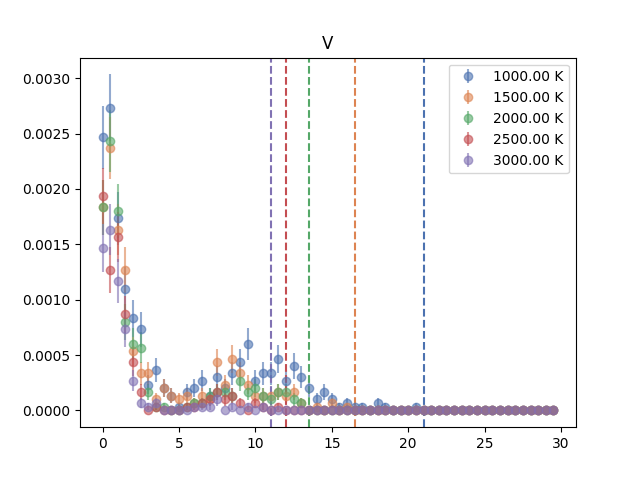

In [22]:
e_list = [1000, 1500, 2000, 2500, 3000]
colors = sns.color_palette('deep', len(e_list))
plt.figure()
for i,e_val in enumerate(e_list):
    opacplt = opac[opac['e']==e_val]
    opacplt_n4 = opac_n4[opac_n4['e']==e_val]
    plt.errorbar(opacplt['b'], opacplt['p_BB'], opacplt['p_BB_err'], fmt = 'o', color = colors[i], alpha = 0.6, label = f'{e_val:.2f} K')
    # plt.errorbar(opacplt_n4['b'], opacplt_n4['p_BB'], opacplt_n4['p_BB_err'], fmt = 's', color = colors[i], alpha = 0.6, label = f'{e_val:.2f} K')
    plt.axvline(opacplt['bmax_BB'].values[0], 0, 1, linestyle='--', color = colors[i])
    # plt.axvline(opacplt_n4['bmax_BB'].values[0], 0, 1, linestyle='-', color = colors[i])
    plt.title('V')
plt.legend()

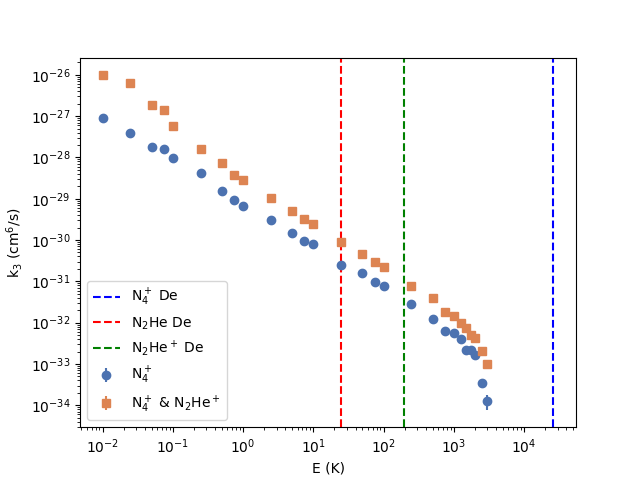

In [23]:
plt.figure()
plt.errorbar(k3['e'], k3['k_BB'], k3['k_BB_err'], fmt='o', color=colors[0], label=r'N$_4^+$')
plt.errorbar(k3_n4['e'], k3_n4['k_BB'], k3_n4['k_BB_err'], fmt='s', color=colors[1], label=r'N$_4^+$ & N$_2$He$^+$')
plt.axvline(N4p_de/K2HAR,0,1, linestyle = '--', color = 'b', label = r'N$_4^+$ De')
plt.axvline(N2He_de/K2HAR,0,1, linestyle = '--', color = 'r', label = r'N$_2$He De')
plt.axvline(N2pHe_de/K2HAR,0,1, linestyle = '--', color = 'g', label = r'N$_2$He$^+$ De')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('k$_3$ (cm$^6$/s)')
plt.xlabel('E (K)')
plt.legend()

In [225]:
# Thermal
from scipy.integrate import trapezoid

def thermal_rate(rate_df, T_vals_K, process='BB'):
    BOH2M = 5.2917710903e-11   # a0 to m
    T2S = 2.4188843265857e-17 # Atomic time to seconds
    K2HAR = 3.166811563e-6     # Kelvin to Hartree

    rate_df = rate_df.sort_values('e', ascending=True)
    e_vals = rate_df['e'].values
    k_col = f'k_{process}'
    k_err_col = f'k_{process}_err'
    if k_col not in rate_df.columns:
        raise ValueError(f'Column "{k_col}" not found in DataFrame.')
    
    k_vals = rate_df[k_col].values
    k_err_vals = rate_df[k_err_col].values
    thermal_rates = []
    thermal_rates_err = []

    for T_K in T_vals_K:

        if T_K == 0:
            thermal_rates.append(0.0)
            thermal_rates_err.append(0.0)
            continue

        exp_term = np.exp(-e_vals/T_K)

        num = e_vals**2 * k_vals * exp_term
        den = 2*T_K**3

        num_err = e_vals**2 * k_err_vals * exp_term

        integrand = num/den
        integrand_err = num_err/den
        
        # if T_K == 30:
        #     plt.figure()
        #     plt.plot(e_vals, integrand, '.')
        
        k_thermal = trapezoid(y=integrand, x=e_vals)
        k_thermal_err = trapezoid(y=integrand_err, x=e_vals)

        thermal_rates.append({'T_K': T_K.round(10), 
                              f'k_thermal_{process}': k_thermal,
                              f'k_thermal_{process}_err': k_thermal_err})
        
    return pd.DataFrame(thermal_rates)


Text(0.5, 1.0, 'T = 10 K')

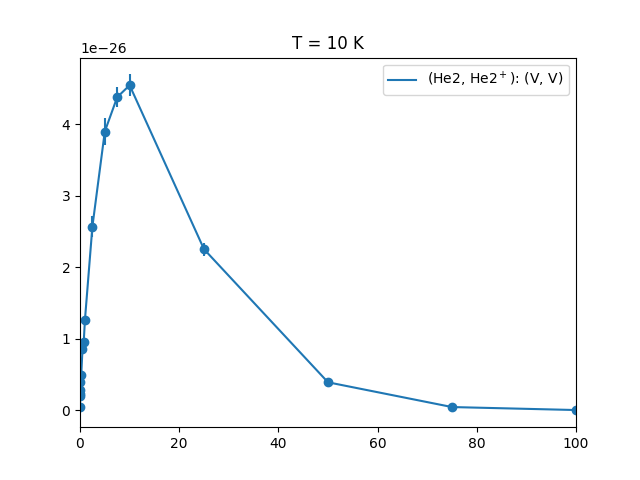

In [110]:
# MB Distribution

tt = 10
plt.figure()
lines1 = plt.plot(k3['e'], k3['k_BB']*k3['e']**2*np.exp(-k3['e']/tt)/2*tt**3, label = '(He2, He2$^+$): (V, V)')
linecolor1 = lines1[0].get_color()
plt.errorbar(k3['e'], k3['k_BB']*k3['e']**2*np.exp(-k3['e']/tt)/2*tt**3, k3['k_BB_err']*k3['e']**2*np.exp(-k3['e']/tt)/2*tt**3, color = linecolor1, fmt = 'o')
plt.xlim(0,10*(tt))
plt.legend()
plt.title(f'T = {tt} K')



In [111]:
def analytical_temp(temps, mu0, alpha):
    '''
    '''
    BOH2M = 5.2917710903e-11   # a0 to m
    T2S = 2.4188843265857e-17 # Atomic time to seconds
    K2HAR = 3.166811563e-6     # Kelvin to Hartree
    fact_rate = (BOH2M*1e2)**6/T2S


    C = (8*np.pi**2/15) * ((2*alpha)**(5/4))*np.sqrt(2/mu0)*fact_rate
    A = C*gamma(9/4)/2

    T_Hartree = temps*K2HAR
    k_analytical = A*(T_Hartree**(-3/4))
    return k_analytical

In [112]:
analytical_temp(t_vals, mu0, N2_alpha)

array([7.05483125e-31, 7.04426749e-31, 7.03374057e-31, ...,
       1.16847609e-31, 1.16831669e-31, 1.16815734e-31], shape=(5000,))

In [ ]:
k =  2*np.pi*np.sqrt(N2_alpha/m12)
k_converted = k*(A)**3
T2S[0]

2.4188843265864e-17

In [216]:
T2S

(2.4188843265864e-17, 's', 2.6e-29)

In [217]:
from tbr.constants import AU2CM, T2S
def langevin(mu12, alpha):
    # Convert a_0^3/t(a.u.) to cm^3/s
    k =  2*np.pi*np.sqrt(alpha/mu12)
    k_converted = k*(AU2CM)**3/T2S[0]
    return k_converted

langevin(m12, N2_alpha)

np.float64(3.150022136938426e-10)

In [201]:
2*np.pi*np.sqrt(N2_alpha/m12)

np.float64(0.05141919915523455)

Text(0.5, 0, 'T (K)')

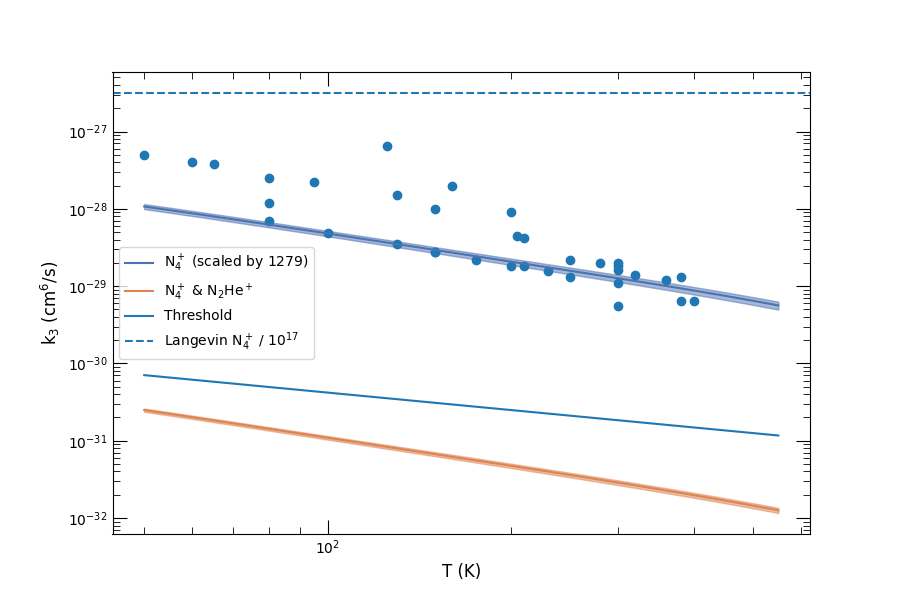

In [218]:
t_vals = np.arange(50,550,0.1)
k_therm = thermal_rate(k3, t_vals)
k_therm_low = k_therm['k_thermal_BB'] - k_therm['k_thermal_BB_err']
k_therm_high = k_therm['k_thermal_BB'] + k_therm['k_thermal_BB_err']

k_therm_n4 = thermal_rate(k3_n4, t_vals)
k_therm_low_n4 = k_therm_n4['k_thermal_BB'] - k_therm_n4['k_thermal_BB_err']
k_therm_high_n4 = k_therm_n4['k_thermal_BB'] + k_therm_n4['k_thermal_BB_err']

k_theory = analytical_temp(t_vals, mu0, N2_alpha)

# Previous results
data = pd.read_csv('results/n4_data.csv')
data = data.iloc[1:]

# Scale factor
scale_t, scale_k3 = data.sort_values('T (K)').iloc[10]['T (K)'], data.sort_values('T (K)').iloc[10]['k3']
scale_up = scale_k3/ k_therm[k_therm['T_K'].apply(lambda x: np.isclose(x, scale_t))]['k_thermal_BB'].values

plt.figure(figsize=(9,6))
lines1 = plt.plot(k_therm['T_K'], k_therm['k_thermal_BB']*scale_up, color = colors[0], label = fr'N$_4^+$ (scaled by {int(scale_up[0])})')
lines2 = plt.plot(k_therm_n4['T_K'], k_therm_n4['k_thermal_BB'], color = colors[1], label = r'N$_4^+$ & N$_2$He$^+$')
linecolor1 = lines1[0].get_color()
linecolor2 = lines2[0].get_color()
plt.fill_between(k_therm['T_K'], k_therm_low*scale_up, k_therm_high*scale_up, color = linecolor1, alpha = 0.5)
plt.fill_between(k_therm_n4['T_K'], k_therm_low_n4, k_therm_high_n4, color = linecolor2, alpha = 0.5)
plt.plot(t_vals, k_theory, label = 'Threshold')
plt.axhline(langevin(m12, N2_alpha)/1e17, linestyle='--', label = r'Langevin N$_4^+$ / 10$^{17}$')
plt.scatter(data['T (K)'], data['k3'])
# Plot parameters
plt.yscale('log')
plt.xscale('log')
plt.legend()
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(direction='in',which='minor',length=5,
                bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=10,
                bottom=True, top=True, left=True, right=True)
plt.ylabel('k$_3$ (cm$^6$/s)', fontsize=12)
plt.xlabel('T (K)', fontsize=12)

In [ ]:
scale_t, scale_up = data.sort_values('T (K)').iloc[4]['T (K)'], data.sort_values('T (K)').iloc[4]['k3']
data.sort_values('T (K)').iloc[4]['k3']/ k_therm[k_therm['T_K'].apply(lambda x: np.isclose(x, scale_t))]['k_thermal_BB']

In [174]:
k_therm[k_therm['T_K'].apply(lambda x: np.isclose(x, scale_t))]

,T_K,k_thermal_BB,k_thermal_BB_err
300,80.0,4.888712e-32,3.854199e-33


In [ ]:
k_therm[k_therm['T_K'] == scale_t]

,T_K,k_thermal_BB,k_thermal_BB_err
300,80.0,4.888712e-32,3.854199e-33


In [178]:
data.sort_values('T (K)').iloc[4]['k3']/ k_therm[k_therm['T_K'].apply(lambda x: np.isclose(x, scale_t))]['k_thermal_BB'].values

array([2454.63440202])

In [50]:
# Pressure calculation
# Find interparticle distance as a function of pressure
# r = n^(-1/3)
# p = nkT : p - pressure, n - number density, k - boltzmann, T - temp
# V/N = 4/3 pi r^3
# V/N = RT/p 
# RT/P = 4/3 pi r^3
# r = 3/4RT/(pi*P)
# But not mass dependent.. 
# 

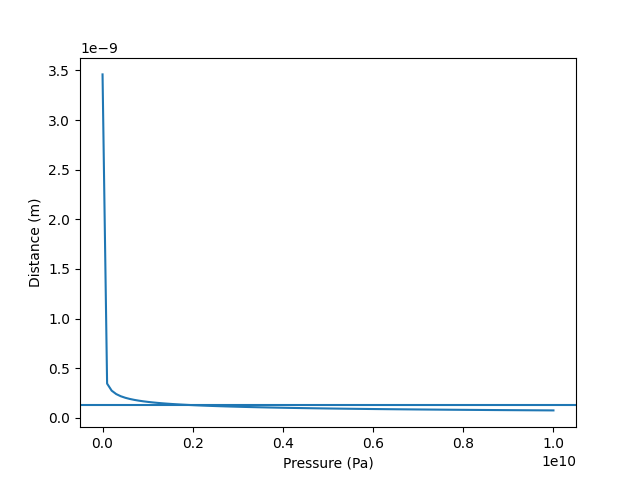

In [97]:
# PV = NkT
# V/N = 4/3 pi d^3
# d = (3kT/4 pi P)^(1/3)
# R_LR = 2[<rA^2>^(1/2) + <rB^2>^(1/2)] == 4r
# Find pressure where d = R_LR = 4r

r_he = 0.31e-10 # A
r_ar = 0.71e-10 # A

lr_he = 4*r_he 
lr_ar = 4*r_ar 
T = 300 # K
kb = 1.380649E-23 

d_p = lambda P: (kb*T/((P))*1e23)**(1/3) # Pa -> bar -> per particle
rho = lambda P: P/(kb*T)

dist = lambda P: (1/rho(P))**(1/3)

px = np.linspace(1e5, 1e10, 100)
plt.figure()
# plt.plot(px, d_p(px))
plt.plot(px, dist(px))
plt.axhline(lr_he, 0, 1, label = 'He')
# plt.axhline(lr_ar, 0, 1, label = 'Ar')
plt.xlabel('Pressure (Pa)')
plt.ylabel('Distance (m)')
plt.show()

In [ ]:
# P = n k T
n = 0.1785 # kg/m^3
P = n*kb*300
P*1e-5/1e-23

0.0007393375395000001

In [77]:
print(lr_he)
print(lr_ar)

1.24e-10
2.84e-10


In [227]:
print(N4p_c4, N4p_c8)
print(N2pHe_c4, N2pHe_c8)
print(N2He_c6, N2He_c12)

5.76982600462627 100.0495640001369
0.701826788866821 201.0938322938087
10.197024275283358 329002.64093218325


In [229]:
np.argmin(v_N4p(x))

np.int64(20)

In [231]:
x[20]

np.float64(2.4503006012024047)